#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

No GPU devices found.


In [3]:
co_df = pd.read_csv("/content/drive/MyDrive/TA/Dataset/co.csv")
wind_df=  pd.read_csv("/content/drive/MyDrive/TA/Dataset/wind.csv")
co_sea = pd.read_csv("/content/drive/MyDrive/TA/Dataset/Sea/CO_Sea_wind.csv")

#2. Class Definition

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)



class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Use RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='swish',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        # self.fourier_features = FourierFeatureMapping(mapping_size=mapping_size, sigma=sigma, trainable_B=trainable_B)

        # dummy_input = tf.keras.Input(shape=(3,))
        # _ = self.fourier_features(dummy_input)

        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is a Tensor
        X = tf.reshape(X, (-1, 3))  # Ensure input is 2D (batch_size, features) for [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z)
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        return self.out(Z)


class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self):
        return self.get_r_fn(t=self.t, x=self.x, y=self.y, model=self.model, lambd = self.lambd, fun_r=self.fun_r)

    def loss_fn(self, X, u):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        r = self.get_r()
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u):
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)

        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, inverse=True, N=None, min_loss=None, timeout=None):
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is Tensor
        u = tf.convert_to_tensor(u, dtype=tf.float32)  # Ensure u is Tensor

        @tf.function
        def train_step():
          loss, grads = self.get_grad(X, u)
          optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
          return loss

        def loss_callback():
            loss = train_step()
            self.current_loss = loss.numpy()

            print(f"Iteration {self.iter}, Loss: {self.current_loss}")
            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        if timeout is not None:
            while time.time() - start_time < timeout:
                loss_callback()
        elif N is not None:
            for _ in range(N):
                loss_callback()
        elif min_loss is not None:
            while self.current_loss > min_loss:
                loss_callback()

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]

    #     # Reshape into [Nt+1, Nx+1, Ny+1]
    # Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
    # U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

    #     # Create meshgrid for visualization
    # T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
    # self.T_pred, self.X_pred, self.Y_pred = T, X, Y

    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

def plot_solution_slice(U, T, X, Y, time_idx=0):
    """Plot solution slice at specific time index"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X[time_idx], Y[time_idx], U[time_idx],
                          cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(t,x,y)')
    ax.set_title(f'Solution at t = {T[time_idx,0,0]:.2f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        # Call init of base class
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)  # Ensure layers are initialized
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        # Combine neural network weights with lambda parameter
        return super().trainable_variables + [self.lambd]

class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param, X, u,
                               N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None, modified=False, **kwargs):
        self.changed = False
        self.lambd_list = []
        super().solve_with_TFoptimizer(optim_fwd, X, u, N=N_fwd, min_loss=min_loss_fwd, timeout=timeout_fwd, **kwargs)

        # Add parameters after fitting
        # with given data.
        self.model.add_param()
        self.changed = True

        print('\n\nFinding PDE parameters.')

        if modified is True:

            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param()

                # Perform gradient descent step, update the weights of the model.
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss

            def loss_callback():
                loss = train_step_param()

                self.current_loss = loss.numpy()
                callback()

        else:
            @tf.function
            def train_step_param_unmodified():
                 with tf.GradientTape() as tape:
                    tape.watch(self.model.lambd)
                    # phi_r is calculated only after
                    # variables are added.
                    # Compute phi_r
                    r = self.get_r()
                    loss = r

                 grad_lambd = tape.gradient(loss, self.model.lambd)
                 optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                 return loss


            def loss_callback():
                loss = train_step_param_unmodified()
                self.current_loss = loss.numpy()
                callback()



        def callback():
                lambd = self.model.lambd.numpy()
                self.model.lambd_list.append(lambd)

                if self.iter % 10 == 0:
                    print('It {:05d}: loss = {:10.8e} lambda = '.format(self.iter, self.current_loss) + str(lambd))

                self.hist.append(self.current_loss)
                self.iter += 1

        if N_param is not None:
            for _ in range(N_param):
                loss_callback()

            print ('{} iterations reached.'.format(N_param))

        elif min_loss_param is not None:
            while True:
                loss_callback()

                if self.current_loss < min_loss_param:
                    print ('Loss is reached. Current loss: {:10.8e}'.format(self.current_loss))
                    break

        elif timeout_param is not None:
            t0 = time.time()
            stop_after = time.time() + timeout_param

            while True:
                loss_callback()

                if time.time() > stop_after:
                    print ('Timeout is reached. Time elapsed: {} seconds'.format(time.time()-t0))
                    break

    def loss_fn(self, X, u):
        # Initialize loss
        loss = 0
        phi_r = 0

        # phi_r is calculated only after
        # variables are added.
        if self.changed is not False:
            # Compute phi_r
            r = self.get_r()
            phi_r =r
            loss += phi_r

        else:
            u_pred = self.model(X)
            loss += tf.reduce_mean(tf.square(u - u_pred))

        return loss, phi_r

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
            # print('It {:05d}: loss = {:10.8e}'.format(self.iter,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

# 3. Data PreProcessing and Training-Testing Split

In [4]:
co_df = co_df.drop(columns=['Unnamed: 0'])
co_sea = co_sea.drop(columns=['Unnamed: 0'])
co_df.dropna(inplace = True)


In [ ]:
# co_sea.loc[co_sea.index[-528:], 'date'] = pd.to_datetime(co_sea.loc[co_sea.index[-528:], 'date']).dt.date

In [5]:
co_df['date'] = pd.to_datetime(co_df['date'])
start_date = datetime.datetime(2023, 5, 1)
co_df = co_df[(co_df['date'] >= start_date)]

co_sea['date'] = pd.to_datetime(co_sea['date'])
start_date = datetime.datetime(2023, 5, 1)
co_sea = co_sea[(co_sea['date'] >= start_date)]
co_sea.sort_values(by=['date','longitude','latitude'], inplace=True)

In [ ]:
co_df

,x_coord,y_coord,date,CO_mean,city
4796,106.900369,-6.255422,2023-05-01,0.032034,JakartaTimur
4798,107.414924,-6.897186,2023-05-01,0.027589,BandungBarat
4799,108.566579,-7.376339,2023-05-01,0.032887,Banjar
4800,106.651931,-6.182884,2023-05-01,0.031304,KotaTangerang
4801,107.788766,-7.359739,2023-05-01,0.029764,Garut
...,...,...,...,...,...
33840,107.980880,-6.825126,2025-04-29,0.025505,Sumedang
33841,107.414924,-6.897186,2025-04-29,0.024199,BandungBarat
33842,108.141338,-7.497079,2025-04-29,0.024988,Tasikmalaya
33843,107.432169,-6.595011,2025-04-29,0.027553,Purwakarta


In [ ]:
co_sea

,latitude,longitude,date,WS10M,WD10M,MeanCO
1339,-6.581827,105.088452,2023-05-01,3.10,259.6,0.030538
1685,-6.484046,105.092437,2023-05-01,3.10,259.6,0.030138
992,-6.681646,105.092437,2023-05-01,3.10,259.6,0.030841
648,-6.780446,105.092437,2023-05-01,3.28,263.4,0.031580
289,-6.877330,105.096213,2023-05-01,3.28,263.4,0.032612
...,...,...,...,...,...,...
62045,-7.074490,108.957661,2025-04-29,2.78,151.1,0.021904
62580,-6.977997,108.959799,2025-04-29,2.78,151.1,0.021521
59421,-7.670531,108.960063,2025-04-29,3.26,127.9,0.021010
63112,-6.876551,108.974448,2025-04-29,2.78,151.1,0.023773


In [6]:
co_df = co_df[co_df.CO_mean>=0]
co_sea = co_sea[co_sea.MeanCO>=0]
co_sea.rename(columns={'longitude':'x_coord', 'latitude':'y_coord',"MeanCO":"CO_mean"}, inplace=True)

co_sea["u10"] = -co_sea.WS10M*np.sin(co_sea.WD10M*np.pi/180)
co_sea["v10"] = -co_sea.WS10M*np.cos(co_sea.WD10M*np.pi/180)
co_sea = co_sea[["x_coord","y_coord","CO_mean","u10","v10","date"]]
co_sea["city"] = "Sea"

wind_df['date'] = pd.to_datetime(wind_df['date'])
co_df['date'] = pd.to_datetime(co_df['date'])
df_all = pd.merge(co_df, wind_df[['date', 'city', 'u10', 'v10']],
                     on=['date', 'city'], how='left')

df_all = pd.concat([df_all,co_sea],axis=0)

In [ ]:
df_all.describe()

,x_coord,y_coord,date,CO_mean,u10,v10
count,138085.000000,138085.000000,138085,138085.000000,138085.000000,138085.000000
mean,107.159905,-6.816082,2024-04-06 08:58:22.468769280,0.032377,-1.515074,1.837024
min,104.968469,-7.964794,2023-05-01 00:00:00,0.002131,-8.700314,-6.483876
25%,106.148628,-7.397178,2023-10-02 00:00:00,0.027838,-3.325997,0.360903
50%,107.112076,-6.876551,2024-04-09 00:00:00,0.031201,-1.942577,2.094980
75%,108.363237,-6.215191,2024-09-19 00:00:00,0.035728,-0.352703,3.349111
max,108.980321,-5.627853,2025-04-29 00:00:00,0.069865,9.926226,8.373507
std,1.197062,0.641670,NaN,0.006444,2.804960,2.143174


In [ ]:
df_all

,x_coord,y_coord,date,CO_mean,city,u10,v10
0,106.900369,-6.255422,2023-05-01,0.032034,JakartaTimur,1.850147,-0.191194
1,107.414924,-6.897186,2023-05-01,0.027589,BandungBarat,2.014314,0.151457
2,108.566579,-7.376339,2023-05-01,0.032887,Banjar,-1.332068,-0.397107
3,106.651931,-6.182884,2023-05-01,0.031304,KotaTangerang,1.277661,-0.823396
4,107.788766,-7.359739,2023-05-01,0.029764,Garut,1.671072,2.563419
...,...,...,...,...,...,...,...
62045,108.957661,-7.074490,2025-04-29,0.021904,Sea,-1.343525,2.433791
62580,108.959799,-6.977997,2025-04-29,0.021521,Sea,-1.343525,2.433791
59421,108.960063,-7.670531,2025-04-29,0.021010,Sea,-2.572414,2.002570
63112,108.974448,-6.876551,2025-04-29,0.023773,Sea,-1.343525,2.433791


In [9]:
co_sea["u10"]  = co_sea.groupby(['x_coord','y_coord'])['u10'].transform('mean')
co_sea["v10"]  = co_sea.groupby(['x_coord','y_coord'])['v10'].transform('mean')
wind_df['u10'] = wind_df.groupby('city')['u10'].transform('mean')
wind_df['v10'] = wind_df.groupby('city')['v10'].transform('mean')
co_df['date'] = pd.to_datetime(co_df['date'])
df_all = pd.merge(co_df, wind_df[['date', 'city', 'u10', 'v10']],
                     on=['date', 'city'], how='left')

df_all = pd.concat([df_all,co_sea],axis=0)

In [12]:
#Convert to Numerical Value
df_all['time'] = (df_all['date'] - df_all['date'].min()).dt.days
scale = 1e-2
df_all.CO_mean = df_all.CO_mean/scale


In [13]:
df_all

,x_coord,y_coord,date,CO_mean,city,u10,v10,time
0,106.900369,-6.255422,2023-05-01,3.203351,JakartaTimur,-0.114501,-0.089835,0
1,107.414924,-6.897186,2023-05-01,2.758902,BandungBarat,-0.419523,0.591405,0
2,108.566579,-7.376339,2023-05-01,3.288658,Banjar,-0.748268,1.851568,0
3,106.651931,-6.182884,2023-05-01,3.130434,KotaTangerang,-0.485871,-0.356253,0
4,107.788766,-7.359739,2023-05-01,2.976366,Garut,-1.483096,1.613819,0
...,...,...,...,...,...,...,...,...
62045,108.957661,-7.074490,2025-04-29,2.190426,Sea,-0.600471,2.008430,729
62580,108.959799,-6.977997,2025-04-29,2.152061,Sea,-0.604710,2.021437,729
59421,108.960063,-7.670531,2025-04-29,2.101015,Sea,-1.019624,2.015254,729
63112,108.974448,-6.876551,2025-04-29,2.377350,Sea,-0.628642,2.034432,729


In [14]:
df_all.describe()

,x_coord,y_coord,date,CO_mean,u10,v10,time
count,138085.000000,138085.000000,138085,138085.000000,138085.000000,138085.000000,138085.000000
mean,107.159905,-6.816082,2024-04-06 08:58:22.468769280,3.237747,-1.456840,1.819333,341.373871
min,104.968469,-7.964794,2023-05-01 00:00:00,0.213090,-3.497820,-0.709391,0.000000
25%,106.148628,-7.397178,2023-10-02 00:00:00,2.783764,-2.126106,0.911942,154.000000
50%,107.112076,-6.876551,2024-04-09 00:00:00,3.120100,-1.240484,2.031296,344.000000
75%,108.363237,-6.215191,2024-09-19 00:00:00,3.572849,-0.623872,2.747545,507.000000
max,108.980321,-5.627853,2025-04-29 00:00:00,6.986520,0.024760,3.746333,729.000000
std,1.197062,0.641670,NaN,0.644400,0.911623,1.195707,206.803450


In [ ]:
filtered_list = []

full_dates = pd.date_range(start=df_all['date'].min(), end=df_all['date'].max(),freq='D')
df2 = (df_all.set_index('date').groupby(['city', 'x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0, 1, 2]).rename_axis('date').reset_index())
df2['CO_mean'] = (df2.groupby(['city', 'x_coord', 'y_coord'])['CO_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))


np.random.seed(42)
for city, subdf in df_all.groupby('city'):
    if city == 'Sea':
        # Filter per (x_coords, y_coords) within 'Sea'
        for (x, y), subsubdf in subdf.groupby(['x_coord', 'y_coord']):
            signal = subsubdf['CO_mean'].values
            n = len(signal)

            # Low-pass filter
            fft_vals = np.fft.fft(signal)
            freqs = np.fft.fftfreq(n, d=1)
            cutoff = 0.1
            mask = np.abs(freqs) < cutoff
            filtered_fft = fft_vals * mask
            filtered_signal = np.fft.ifft(filtered_fft).real

            subsubdf = subsubdf.copy()
            subsubdf['CO_filtered'] = filtered_signal
            filtered_list.append(subsubdf)
    else:
        # Process non-Sea cities as usual
        signal = subdf['CO_mean'].values
        n = len(signal)

        fft_vals = np.fft.fft(signal)
        freqs = np.fft.fftfreq(n, d=1)
        cutoff = 0.1
        mask = np.abs(freqs) < cutoff
        filtered_fft = fft_vals * mask
        filtered_signal = np.fft.ifft(filtered_fft).real

        subdf = subdf.copy()
        subdf['CO_filtered'] = filtered_signal
        filtered_list.append(subdf)

# Combine all back
filtered_df = pd.concat(filtered_list, ignore_index=True)
filtered_df = df_all.merge(
    filtered_df[['date', 'city', 'x_coord', 'y_coord', 'CO_filtered']],
    on=['date', 'city', 'x_coord', 'y_coord'],
    how='left'
)

In [16]:
from matplotlib.ticker import FuncFormatter

# Formatter untuk sumbu-y dalam bentuk 10^-2
def format_y(val, pos):
    return f"{val:.1f}"

cities = filtered_df['city'].unique()

for city in cities:
    city_df = filtered_df[filtered_df['city'] == city]

    plt.figure(figsize=(12, 4))
    plt.plot(city_df['date'], city_df['CO_mean'], label='Data Asli', alpha=0.6)
    plt.plot(city_df['date'], city_df['CO_filtered'], label=r'Data Hasil $\it{Filtering}$', linewidth=2)
    plt.title(f'Tren Konsentrasi CO – {city}')
    plt.xlabel('Waktu $(t)$')
    plt.ylabel('Konsentrasi CO\n$(10^{-2})$ mol/m²')  # Gunakan LaTeX untuk eksponen

    # Terapkan formatter ke sumbu-y
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y))

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [17]:
filtered_df = filtered_df[filtered_df.CO_filtered>=0]
filtered_df[["date","x_coord","y_coord","u10","v10","city","CO_filtered"]].describe()

,date,x_coord,y_coord,u10,v10,CO_filtered
count,138085,138085.000000,138085.000000,138085.000000,138085.000000,138085.000000
mean,2024-04-06 08:58:22.468769024,107.159905,-6.816082,-1.456840,1.819333,3.237747
min,2023-05-01 00:00:00,104.968469,-7.964794,-3.497820,-0.709391,1.797669
25%,2023-10-02 00:00:00,106.148628,-7.397178,-2.126106,0.911942,2.835931
50%,2024-04-09 00:00:00,107.112076,-6.876551,-1.240484,2.031296,3.100435
75%,2024-09-19 00:00:00,108.363237,-6.215191,-0.623872,2.747545,3.513710
max,2025-04-29 00:00:00,108.980321,-5.627853,0.024760,3.746333,6.249431
std,NaN,1.197062,0.641670,0.911623,1.195707,0.564149


In [18]:
filtered_df[["date","x_coord","y_coord","u10","v10","city","CO_filtered"]]

,date,x_coord,y_coord,u10,v10,city,CO_filtered
26,2023-05-01,107.610720,-7.100013,-0.419523,0.591405,Bandung,2.567886
66,2023-05-02,107.610720,-7.100013,-0.419523,0.591405,Bandung,2.690589
99,2023-05-03,107.610720,-7.100013,-0.419523,0.591405,Bandung,2.783243
112,2023-05-04,107.610720,-7.100013,-0.419523,0.591405,Bandung,2.832568
149,2023-05-05,107.610720,-7.100013,-0.419523,0.591405,Bandung,2.833438
...,...,...,...,...,...,...,...
21953,2025-04-23,107.299065,-6.737873,-0.606351,-0.157201,WadukCirata,2.503980
21992,2025-04-25,107.299065,-6.737873,-0.606351,-0.157201,WadukCirata,2.520537
22061,2025-04-27,107.299065,-6.737873,-0.606351,-0.157201,WadukCirata,2.604909
22116,2025-04-28,107.299065,-6.737873,-0.606351,-0.157201,WadukCirata,2.739899


In [19]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(96659, 3), dtype=float32, numpy=
array([[476.       , 105.096214 ,  -6.87733  ],
       [510.       , 105.97304  ,  -6.8792458],
       [453.       , 107.1447   ,  -5.9577236],
       ...,
       [321.       , 106.19975  ,  -5.978065 ],
       [682.       , 106.85364  ,  -7.570846 ],
       [649.       , 107.557    ,  -5.9234037]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(96659, 1), dtype=float32, numpy=
array([[2.897831 ],
       [3.56744  ],
       [3.3115928],
       ...,
       [2.7494628],
       [2.6119561],
       [3.2089508]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(41426, 3), dtype=float32, numpy=
array([[342.       , 105.84744  ,  -5.79262  ],
       [240.       , 107.65512  ,  -6.244249 ],
       [350.       , 108.21929  ,  -7.3602247],
       ...,
       [503.       , 108.3776   ,  -6.279631 ],
       [ 40.       , 108.96006  ,  -7.670531 ],
       [407.       , 108.852264 ,  -7.269178 ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(41426, 1), dtype=float32, numpy=
array([[2.9371626],
       [3.6008308],
       [2.7082477],
       ...,
       [4.1683455],
       [2.7768583],
       [2.9304063]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(96659, 1), dtype=float32, numpy=
array([[-2.9528883 ],
       [-1.5104146 ],
       [-1.3194137 ],
       ...,
       [-0.60990775],
       [-2.654659  ],
       [-0.91129804]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(96659, 1), dtype=float32, numpy=
array([[ 3.522457  ],
       [ 2.5868871 ],
       [-0.46451986],
       ...,
       [ 0.30694973],
       [ 2.86323   ],
       [-0.52247196]], dtype=float32)>

# Persiapan Arsitektur PINN

In [ ]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}
n_models = 5

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

#4. Constructing Loss Function

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):

    pde_residual = scale*(u_t + W_u * u_x + W_v * u_y- model.lambd * (u_xx + u_yy))
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y,model):

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t + W_u * u_x + W_v * u_y- model.lambd * (u_xx + u_yy))

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g


### Forward Method

In [ ]:

def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data)

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=1000):

    pde_residual =scale*(u_t + W_u * u_x + W_v * u_y-lambd * (u_xx + u_yy))
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Training Data and Evaluate Data

## PDP Model 1 Inverse

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5,1,1.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 10888, Loss: 0.0032070460729300976
Iteration 10889, Loss: 0.003212664043530822
Iteration 10890, Loss: 0.003209490329027176
Iteration 10891, Loss: 0.00320433359593153
Iteration 10892, Loss: 0.003192821517586708
Iteration 10893, Loss: 0.0031965970993041992
Iteration 10894, Loss: 0.0032043023966252804
Iteration 10895, Loss: 0.003211031900718808
Iteration 10896, Loss: 0.0032122747506946325
Iteration 10897, Loss: 0.003214512951672077
Iteration 10898, Loss: 0.003219870151951909
Iteration 10899, Loss: 0.0032237712293863297
Iteration 10900, Loss: 0.0032258317805826664
Iteration 10901, Loss: 0.003232294227927923
Iteration 10902, Loss: 0.003234977601096034
Iteration 10903, Loss: 0.0032535004429519176
Iteration 10904, Loss: 0.003260396420955658
Iteration 10905, Loss: 0.0032828685361891985
Iteration 10906, Loss: 0.0032879251521080732
Iteration 10907, Loss: 0.00331695144996047
Iteration 10908, Loss: 0.003306253580376506
Iteration 10909, L

In [ ]:
path = dir + "COModel/Fourier/Fourier2_swish_inv/"
path

'/content/drive/My Drive/TA/COModel/Fourier/Fourier2_swish_inv/'

In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
hists_Adam1 = [None] * n_models

for i in range(n_models):
    hists_Adam1[i] = []

    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

### Loss Graph

len Atempt-0 and init lambda 0.5:  17351
len Atempt-0 and init lambda 1:  17658
len Atempt-0 and init lambda 1.5:  17666
\\
len Atempt-1 and init lambda 0.5:  17733
len Atempt-1 and init lambda 1:  17792
len Atempt-1 and init lambda 1.5:  17629
\\
len Atempt-2 and init lambda 0.5:  17760
len Atempt-2 and init lambda 1:  17602
len Atempt-2 and init lambda 1.5:  17685
\\
len Atempt-3 and init lambda 0.5:  17604
len Atempt-3 and init lambda 1:  17641
len Atempt-3 and init lambda 1.5:  17694
\\
len Atempt-4 and init lambda 0.5:  17690
len Atempt-4 and init lambda 1:  17665
len Atempt-4 and init lambda 1.5:  17638
\\


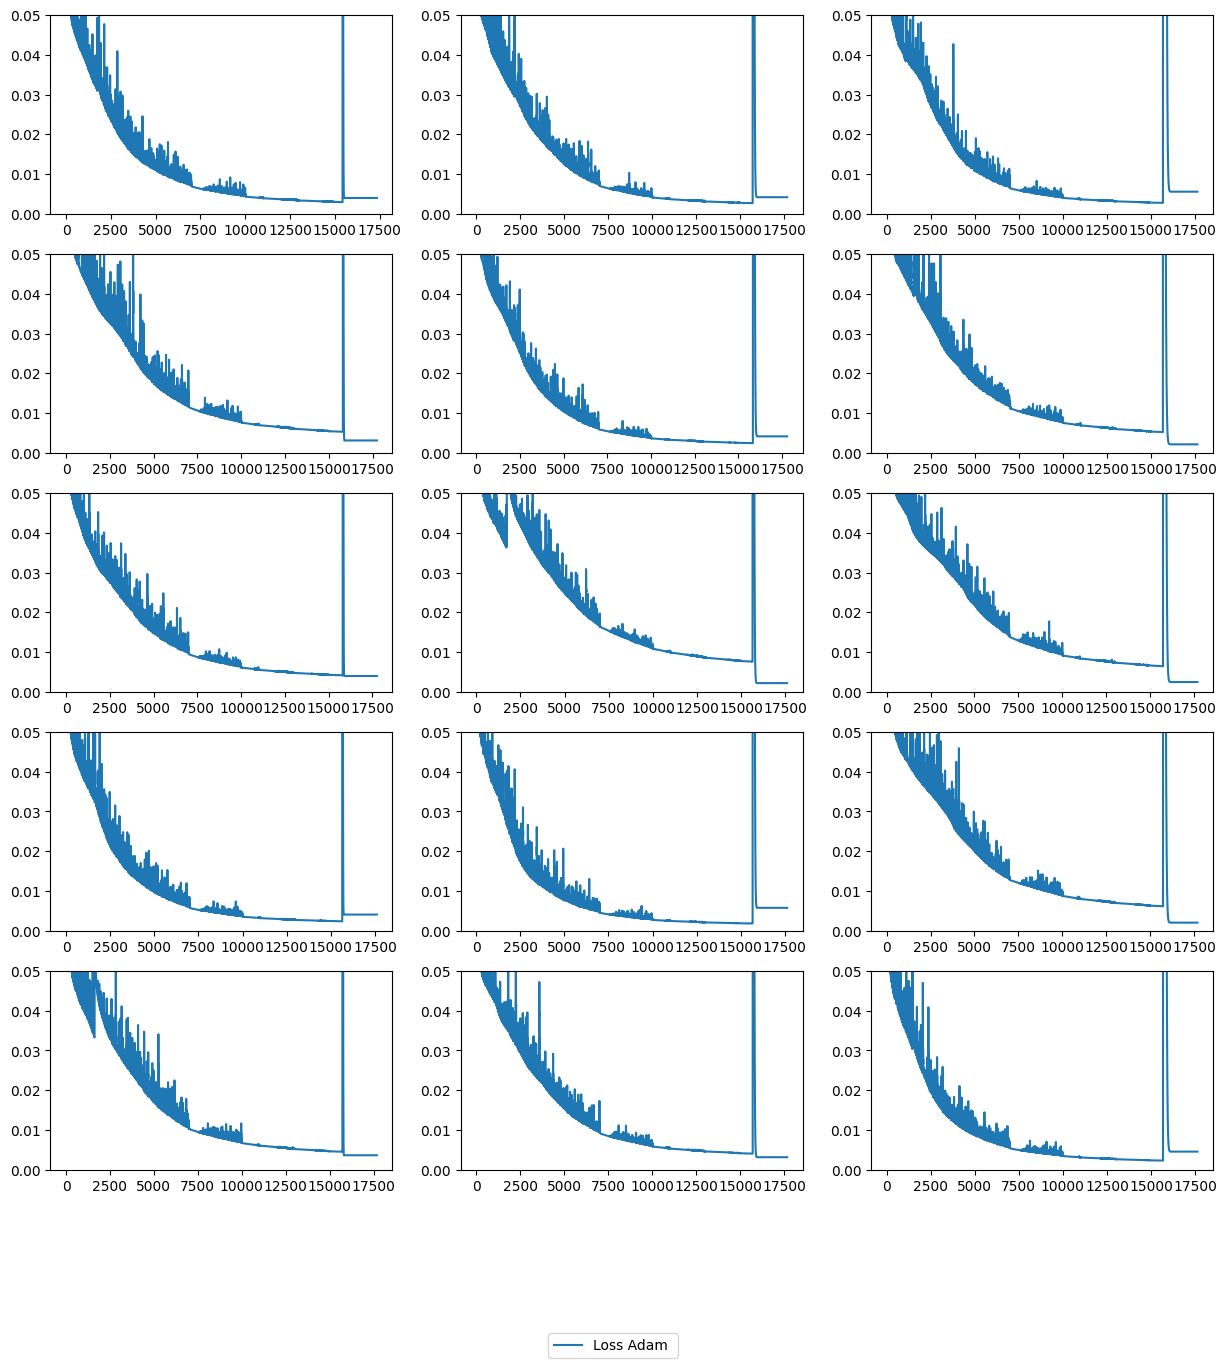

In [ ]:
# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,15))

for i in range(n_models):
  axes[i,0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i,0].set_ylim([0,5e-2])

  axes[i,1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  axes[i,1].set_ylim([0,5e-2])

  axes[i,2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  axes[i,2].set_ylim([0,5e-2])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,1])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,1])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,1])


  print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

  print("\\\\")

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return hists[iter_model][iter_init][0][-1]

df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,0.00001,0.00001,0.00001
Attempt 2,0.00001,0.00001,0.00001
Attempt 3,0.00001,0.00001,0.00001
Attempt 4,0.00001,0.00001,0.00001
Attempt 5,0.00001,0.00001,0.00001


In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)


Adam_0.5    0.00001
Adam_1      0.00001
Adam_1.5    0.00001
dtype: float32


In [ ]:
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

         Adam_0.5   Adam_1  Adam_1.5
Average   0.00001  0.00001   0.00001
StdDev    0.00000  0.00000   0.00000
CV        0.00000  0.00000   0.00000


## PDP Model 1 Forward

In [ ]:
n_models = 5
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

In [ ]:
path = dir + "COModel/Fourier/Fourier2_swish_fwd/"

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

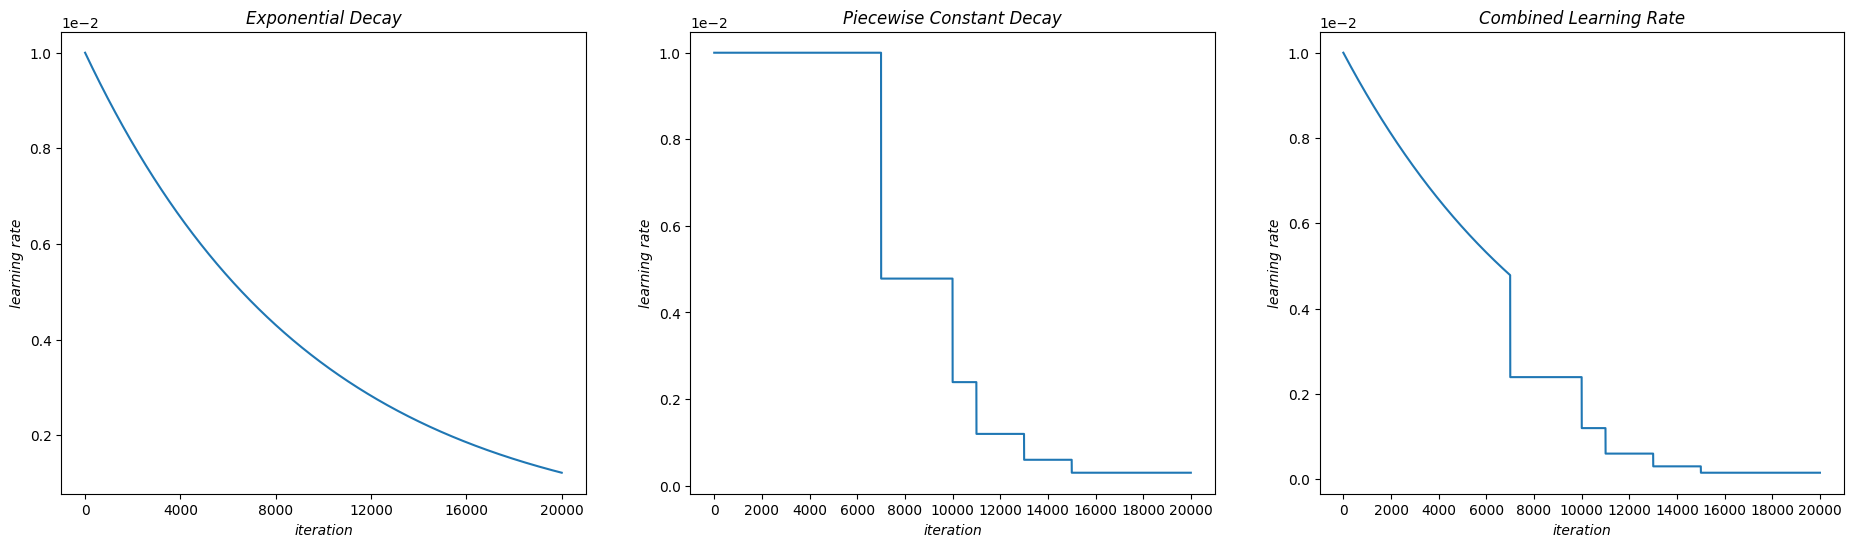

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
pred_lambda = list(df.loc['Average'])
# pred_lambda =[9.999999747378752e-06]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models


for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, timeout=timeout)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 8573, Loss: 4.492623329162598
PDE Loss: 0.00376304612 Data Loss: 0.00439855503 Total Loss: 4.402318
Iteration 8574, Loss: 4.402318000793457
PDE Loss: 0.00363699393 Data Loss: 0.0044031674 Total Loss: 4.40680408
Iteration 8575, Loss: 4.406804084777832
PDE Loss: 0.0037487112 Data Loss: 0.00439401157 Total Loss: 4.39776039
Iteration 8576, Loss: 4.397760391235352
PDE Loss: 0.00364779 Data Loss: 0.00443136226 Total Loss: 4.43501
Iteration 8577, Loss: 4.435009956359863
PDE Loss: 0.00376239535 Data Loss: 0.0044382154 Total Loss: 4.4419775
Iteration 8578, Loss: 4.441977500915527
PDE Loss: 0.003664508 Data Loss: 0.0044368282 Total Loss: 4.44049263
Iteration 8579, Loss: 4.440492630004883
PDE Loss: 0.00371462037 Data Loss: 0.00441519497 Total Loss: 4.41890955
Iteration 8580, Loss: 4.418909549713135
PDE Loss: 0.00369975134 Data Loss: 0.00443863543 Total Loss: 4.44233513
Iteration 8581, Loss: 4.44233512878418
PDE Loss: 0.00374221639 Data 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 8605, Loss: 8.909124374389648
PDE Loss: 0.00113543868 Data Loss: 0.00894586649 Total Loss: 8.94700241
Iteration 8606, Loss: 8.947002410888672
PDE Loss: 0.00111510372 Data Loss: 0.00906825252 Total Loss: 9.06936741
Iteration 8607, Loss: 9.069367408752441
PDE Loss: 0.00113048486 Data Loss: 0.00919572636 Total Loss: 9.1968565
Iteration 8608, Loss: 9.196856498718262
PDE Loss: 0.00112704083 Data Loss: 0.00945294742 Total Loss: 9.45407486
Iteration 8609, Loss: 9.45407485961914
PDE Loss: 0.00112816575 Data Loss: 0.0097760465 Total Loss: 9.77717495
Iteration 8610, Loss: 9.777174949645996
PDE Loss: 0.00112405978 Data Loss: 0.010262005 Total Loss: 10.2631292
Iteration 8611, Loss: 10.263129234313965
PDE Loss: 0.00113280967 Data Loss: 0.0108273253 Total Loss: 10.8284578
Iteration 8612, Loss: 10.828457832336426
PDE Loss: 0.00109956472 Data Loss: 0.0117058055 Total Loss: 11.7069054
Iteration 8613, Loss: 11.706905364990234
PDE Loss: 0.00112

...

Streaming output truncated to the last 5000 lines.
Iteration 8603, Loss: 7.5906853675842285
PDE Loss: 0.00120854424 Data Loss: 0.00755305355 Total Loss: 7.55426216
Iteration 8604, Loss: 7.554262161254883
PDE Loss: 0.00120790571 Data Loss: 0.0075051263 Total Loss: 7.5063343
Iteration 8605, Loss: 7.50633430480957
PDE Loss: 0.00122209021 Data Loss: 0.0074829259 Total Loss: 7.48414803
Iteration 8606, Loss: 7.484148025512695
PDE Loss: 0.00120742072 Data Loss: 0.00752003444 Total Loss: 7.52124166
Iteration 8607, Loss: 7.521241664886475
PDE Loss: 0.00122848793 Data Loss: 0.00754177803 Total Loss: 7.54300642
Iteration 8608, Loss: 7.543006420135498
PDE Loss: 0.00120838615 Data Loss: 0.00756279891 Total Loss: 7.56400728
Iteration 8609, Loss: 7.56400728225708
PDE Loss: 0.00122609676 Data Loss: 0.00750715332 Total Loss: 7.50837946
Iteration 8610, Loss: 7.5083794593811035
PDE Loss: 0.00121440506 Data Loss: 0.00745249353 Total Loss: 7.45370817
Iteration 8611, Loss: 7.453708171844482
PDE Loss: 0.0012

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 8601, Loss: 7.49207067489624
PDE Loss: 0.00198293384 Data Loss: 0.00747850118 Total Loss: 7.48048449
Iteration 8602, Loss: 7.480484485626221
PDE Loss: 0.00195624866 Data Loss: 0.00755524216 Total Loss: 7.55719852
Iteration 8603, Loss: 7.557198524475098
PDE Loss: 0.0019467813 Data Loss: 0.00763767399 Total Loss: 7.63962078
Iteration 8604, Loss: 7.639620780944824
PDE Loss: 0.00199027942 Data Loss: 0.00785533711 Total Loss: 7.85732746
Iteration 8605, Loss: 7.857327461242676
PDE Loss: 0.00192784343 Data Loss: 0.00812291354 Total Loss: 8.12484074
Iteration 8606, Loss: 8.12484073638916
PDE Loss: 0.00202431087 Data Loss: 0.00852961466 Total Loss: 8.5316391
Iteration 8607, Loss: 8.531639099121094
PDE Loss: 0.00191658654 Data Loss: 0.00851380546 Total Loss: 8.51572227
Iteration 8608, Loss: 8.515722274780273
PDE Loss: 0.00200681854 Data Loss: 0.00802810583 Total Loss: 8.03011227
Iteration 8609, Loss: 8.030112266540527
PDE Loss: 0.00193

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 0.00137596158 Data Loss: 0.00851227716 Total Loss: 8.51365376
Iteration 8601, Loss: 8.513653755187988
PDE Loss: 0.00136503449 Data Loss: 0.0086286068 Total Loss: 8.6299715
Iteration 8602, Loss: 8.629971504211426
PDE Loss: 0.00136206637 Data Loss: 0.0087659657 Total Loss: 8.76732731
Iteration 8603, Loss: 8.767327308654785
PDE Loss: 0.00138476922 Data Loss: 0.00898087397 Total Loss: 8.9822588
Iteration 8604, Loss: 8.982258796691895
PDE Loss: 0.00134501397 Data Loss: 0.00942797866 Total Loss: 9.4293232
Iteration 8605, Loss: 9.429323196411133
PDE Loss: 0.00140390138 Data Loss: 0.00995366275 Total Loss: 9.95506668
Iteration 8606, Loss: 9.955066680908203
PDE Loss: 0.00133781356 Data Loss: 0.0107151531 Total Loss: 10.7164907
Iteration 8607, Loss: 10.716490745544434
PDE Loss: 0.0014101906 Data Loss: 0.0110908784 Total Loss: 11.092289
Iteration 8608, Loss: 11.092288970947266
PDE Loss: 0.0013384067 Data Loss: 0.0110944789 Total Loss: 1

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

### Loss Function

len Atempt-0 Lambda ke- 0:  11068
\\
len Atempt-1 Lambda ke- 0:  11100
\\
len Atempt-2 Lambda ke- 0:  11098
\\
len Atempt-3 Lambda ke- 0:  11096
\\
len Atempt-4 Lambda ke- 0:  11099
\\


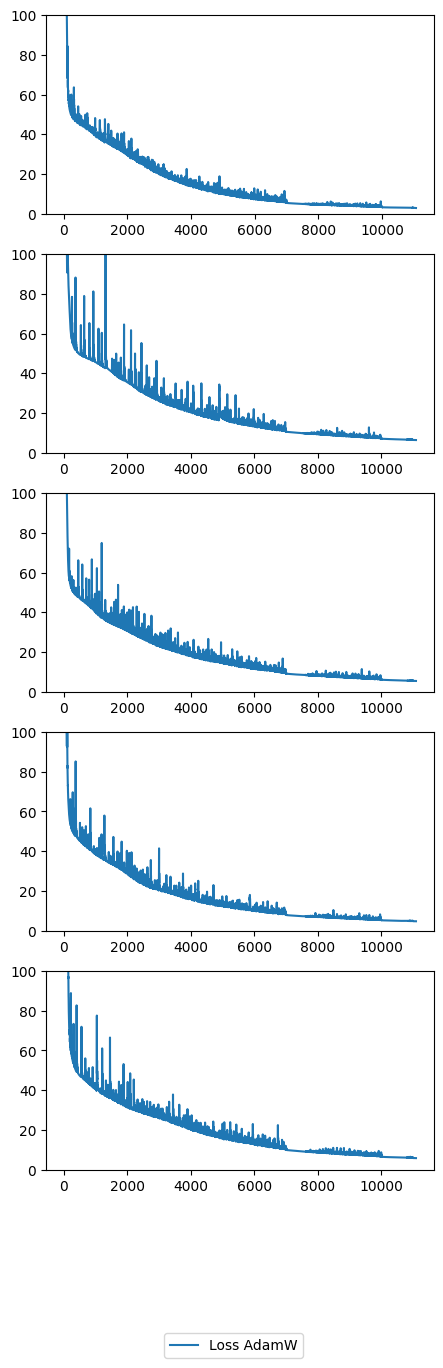

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,15))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,1e2])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.04191225, 1.3252692)"
Attempt 2,"(0.06221493, 1.9685822)"
Attempt 3,"(0.05730621, 1.8196924)"
Attempt 4,"(0.052959196, 1.6632255)"
Attempt 5,"(0.059319563, 1.8718159)"


In [ ]:
preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.06042772, 1.912925)"
Attempt 2,"(0.07493504, 2.3712351)"
Attempt 3,"(0.07148652, 2.2637413)"
Attempt 4,"(0.06862852, 2.160411)"
Attempt 5,"(0.07308136, 2.307724)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  0.069712  0.005682  0.081511   2.203207  0.179525  0.081483


In [ ]:
X_test[:, 0]

<tf.Tensor: shape=(41426,), dtype=float32, numpy=array([342., 240., 350., ..., 503.,  40., 407.], dtype=float32)>

In [ ]:
import os

# Define the directory where you want to save the CSV files
output_dir = dir + "COModel/Fourier/predictions/swish2" # Assuming 'dir' is defined

for i in range(n_models):
    for j in range(len(pred_lambda)):
        # Get the prediction for the current model and initial lambda
        current_pred = preds_Adam_comb[i * len(pred_lambda) + j].numpy()

        # Create a DataFrame from the prediction
        # You might want to include time, x, and y coordinates as well
        X_test_np = X_test.numpy()

        pred_df = pd.DataFrame({
            'time': X_test_np[:, 0],
            'x_coord': X_test_np[:, 1],
            'y_coord': X_test_np[:, 2],
            'predicted_CO_mean': current_pred.flatten()
        })

        # Define the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Save the DataFrame to a CSV file
        pred_df.to_csv(filepath, index=False)

        print(f"Saved prediction to: {filepath}")

Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_1_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_2_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_3_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_4_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_5_lambda_1.csv


Loaded prediction data from: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_1_lambda_1.csv


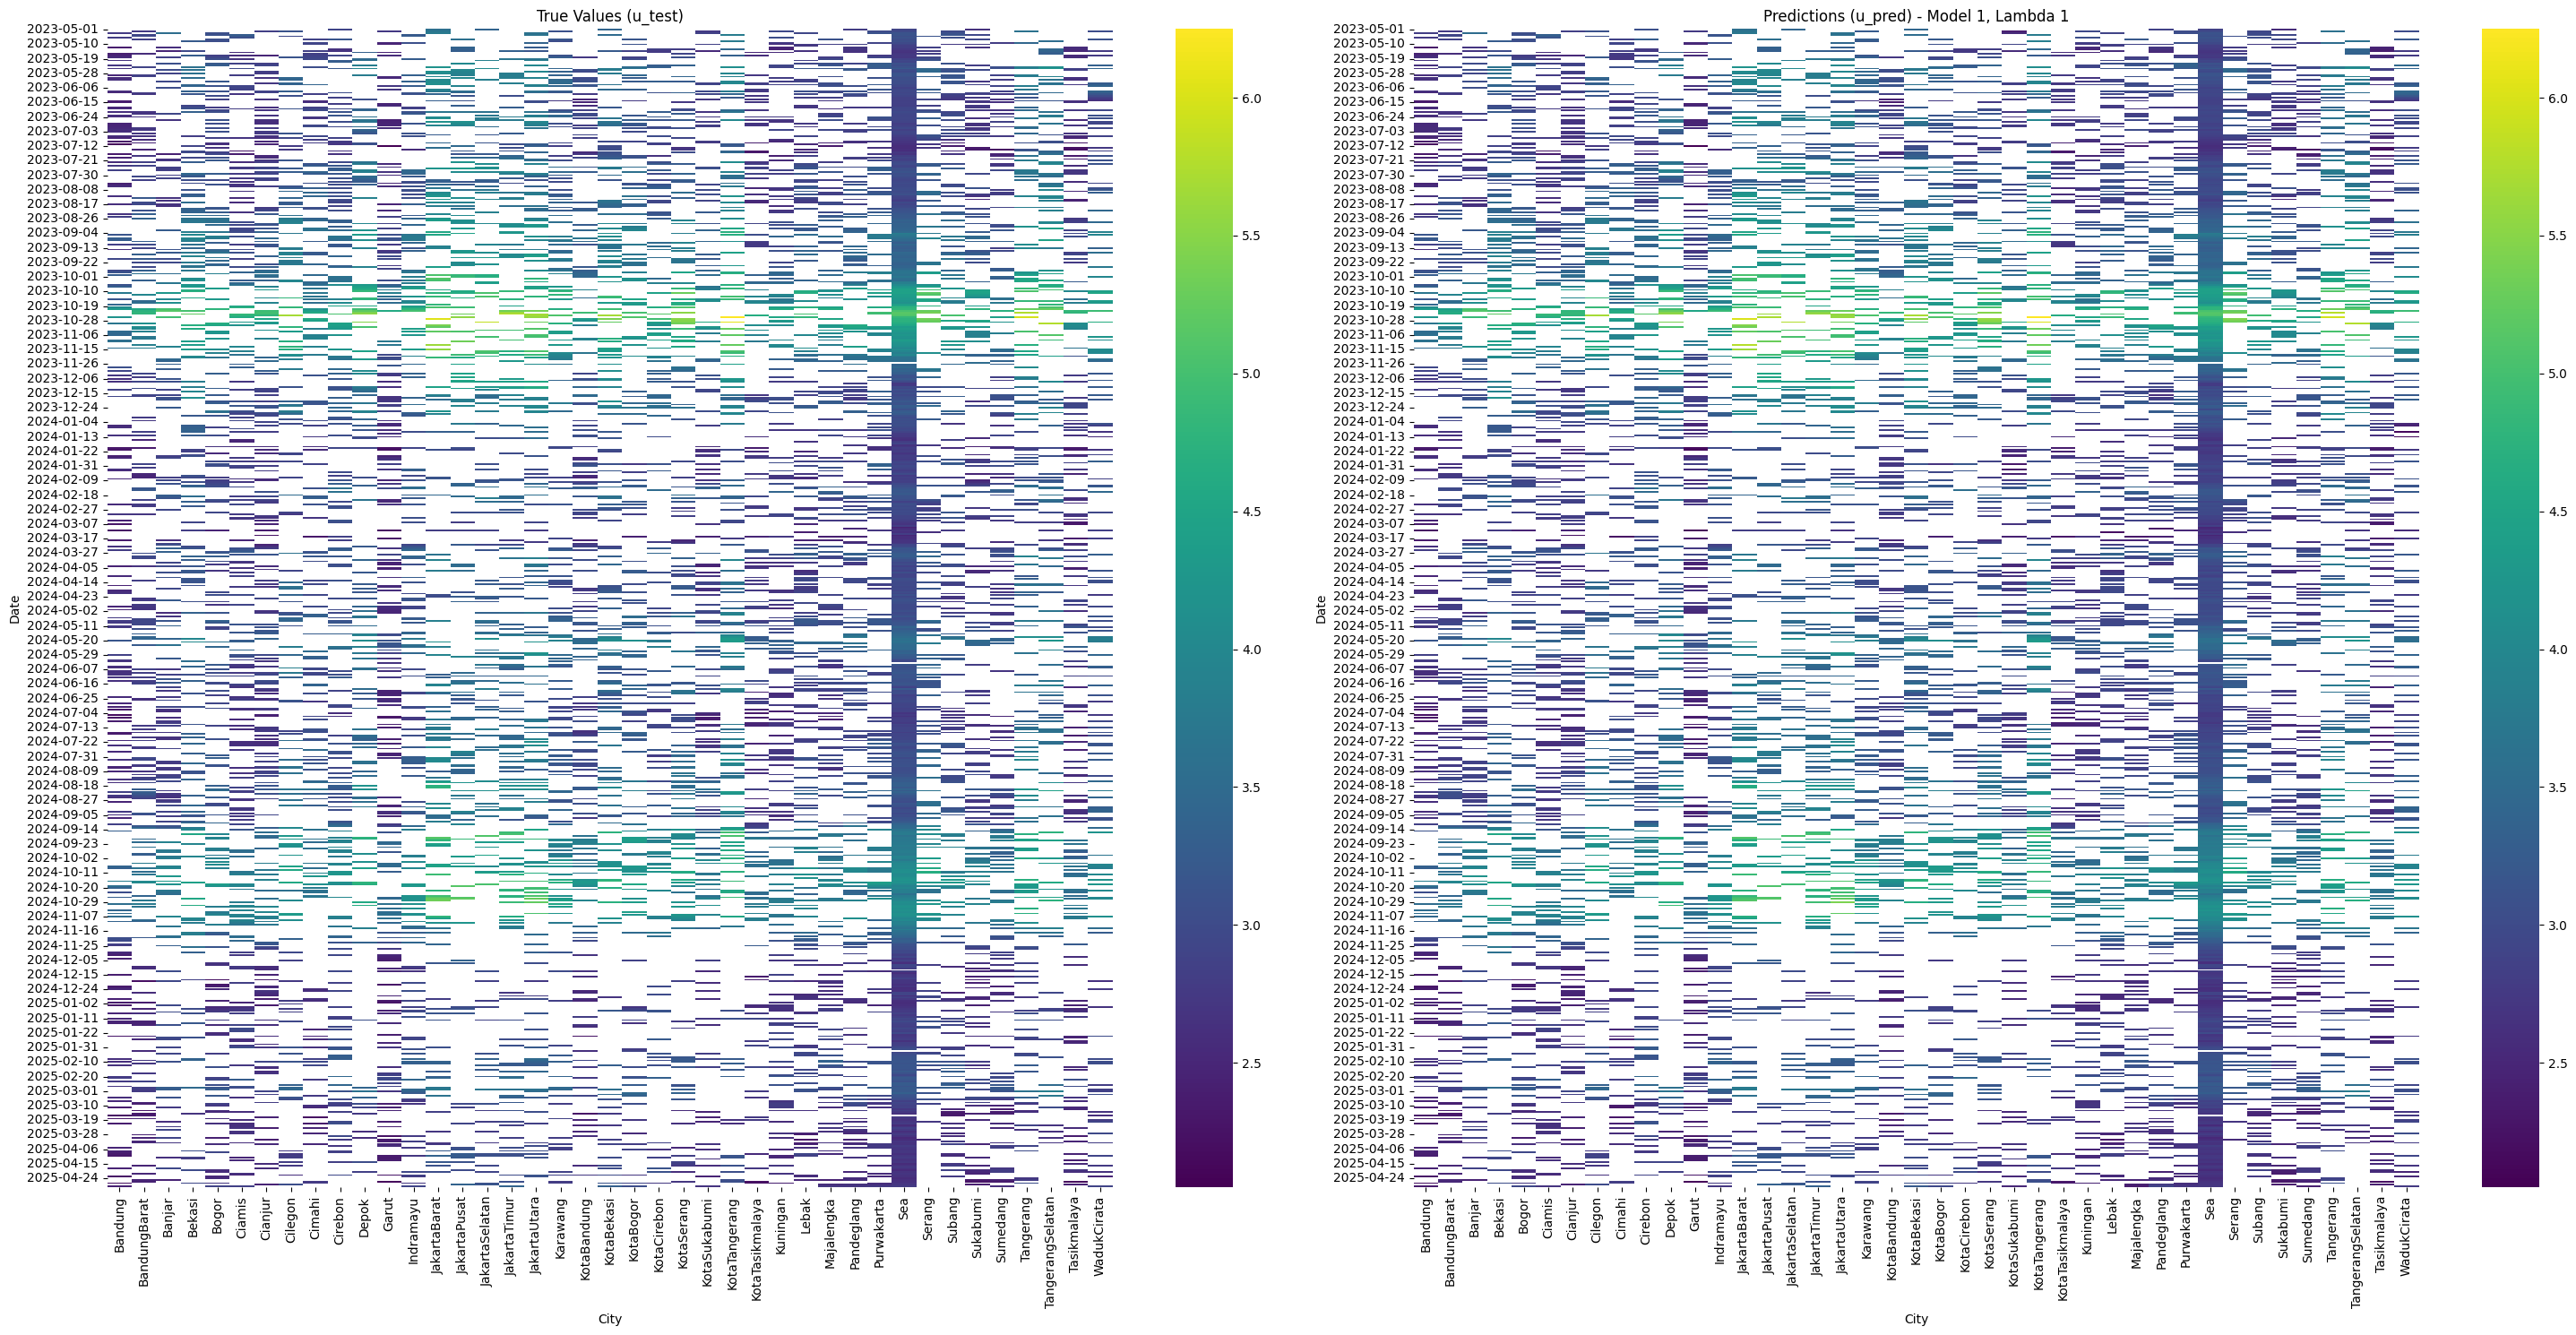

Loaded prediction data from: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_2_lambda_1.csv


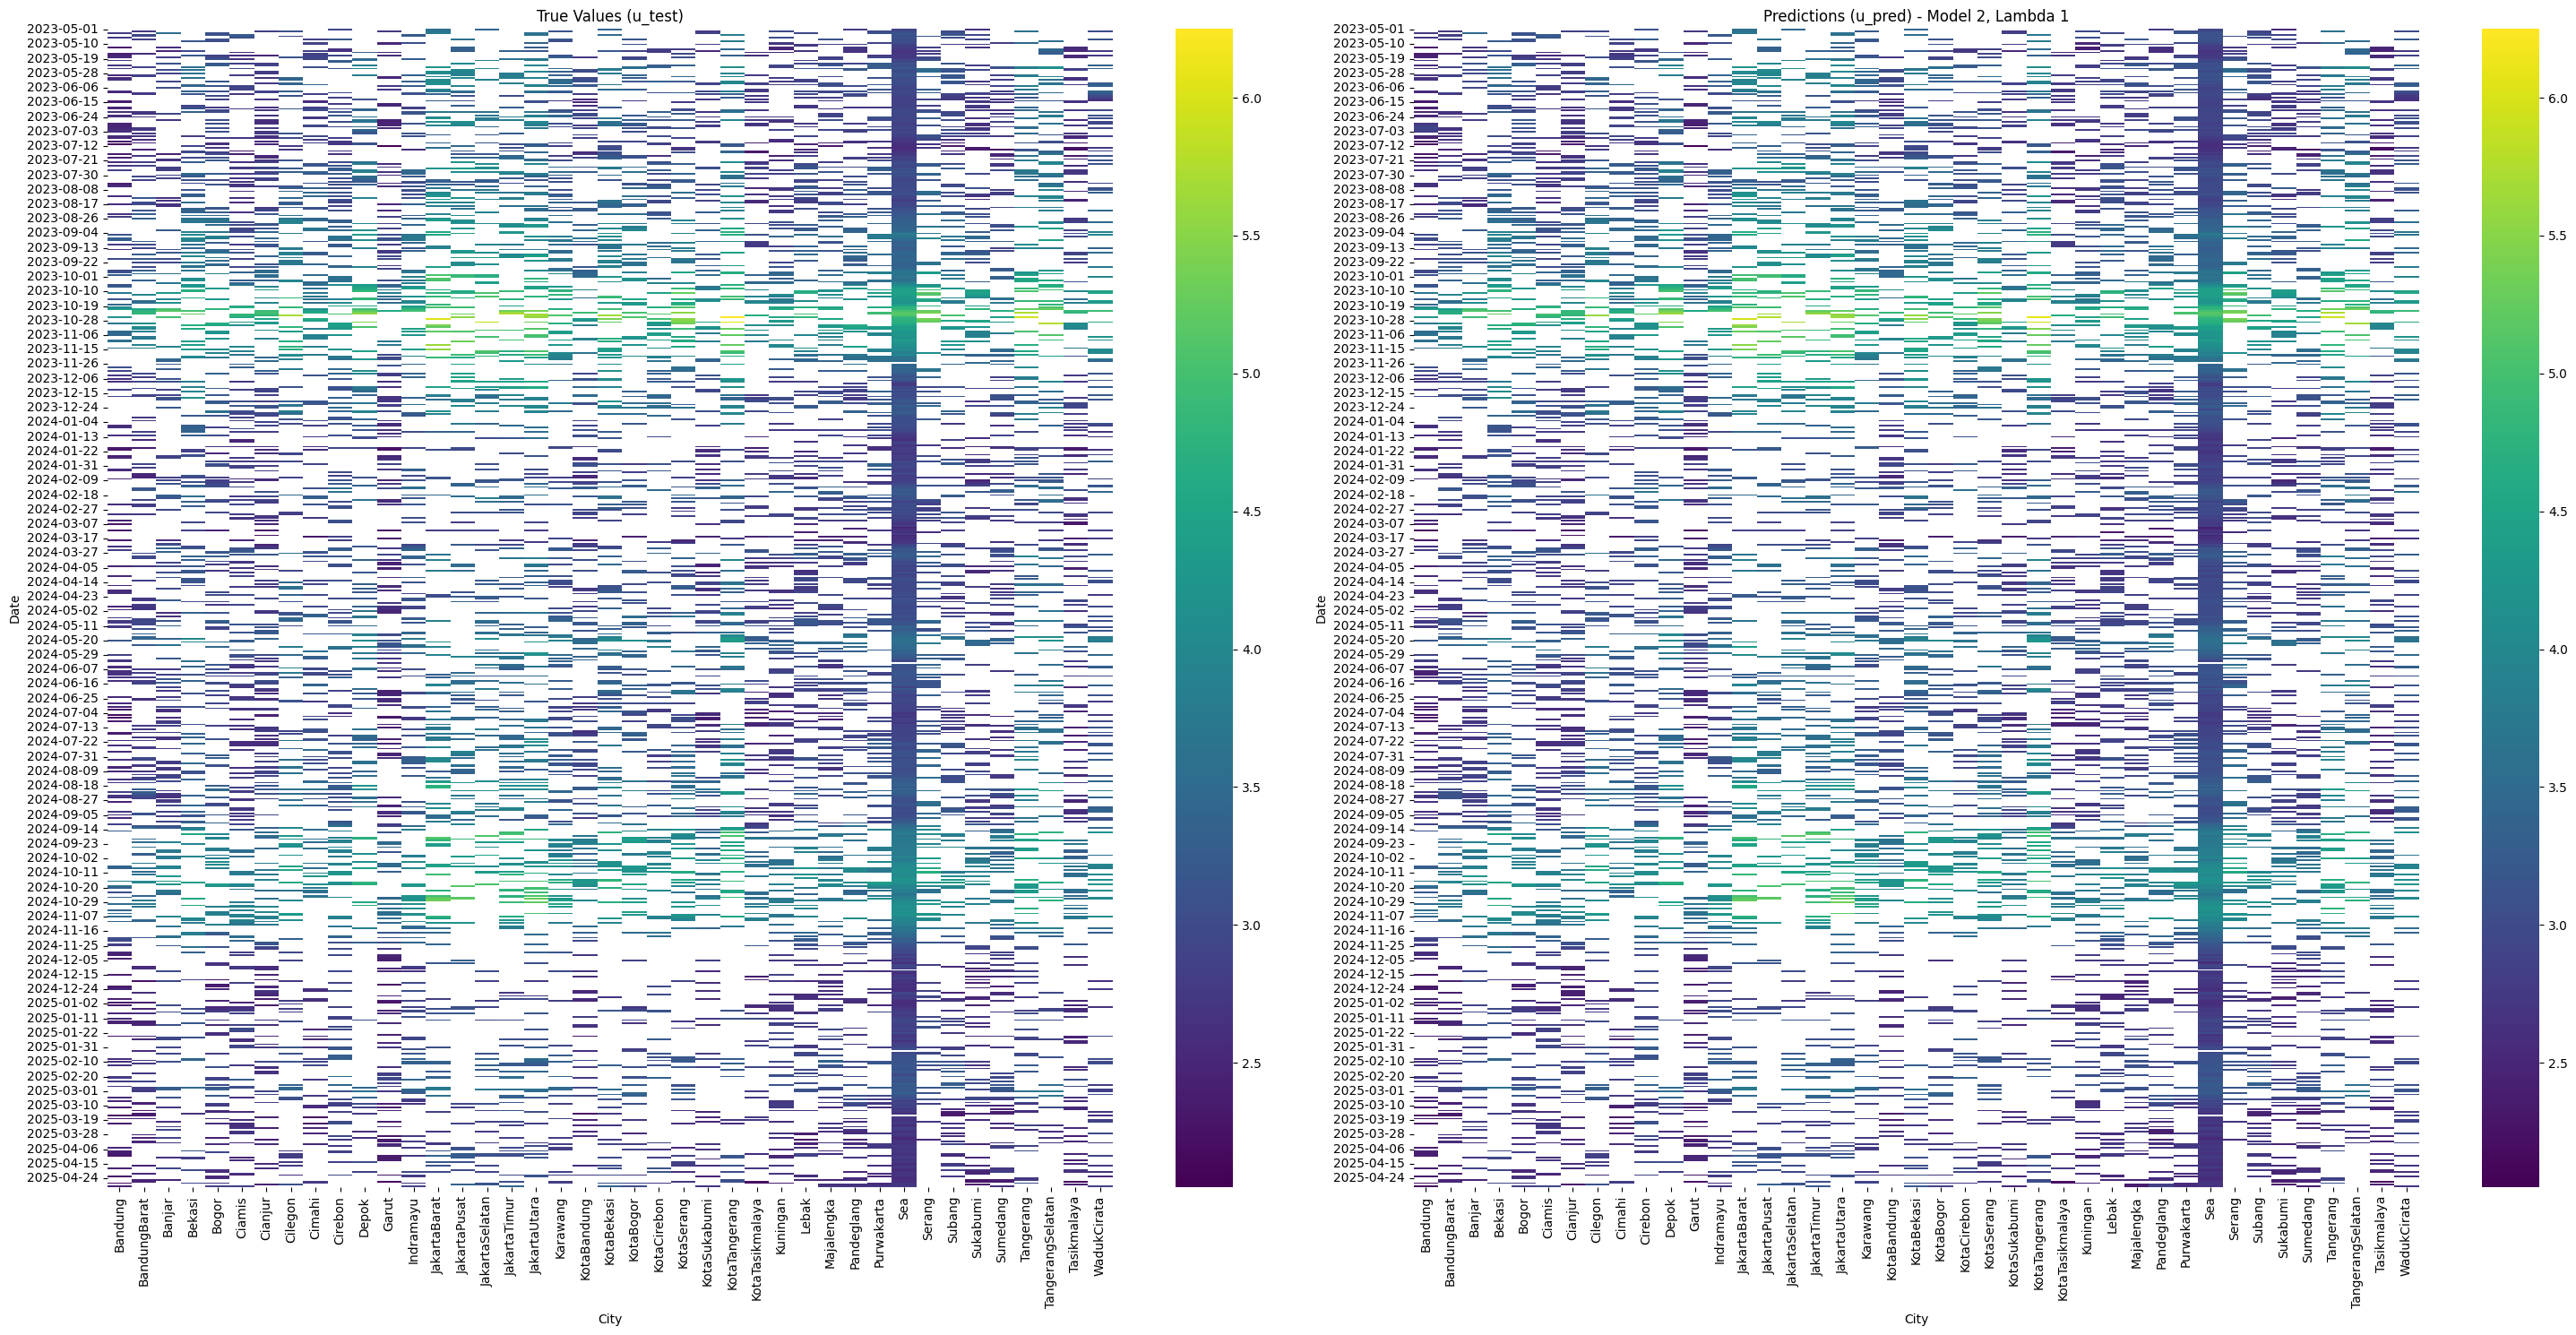

Loaded prediction data from: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_3_lambda_1.csv


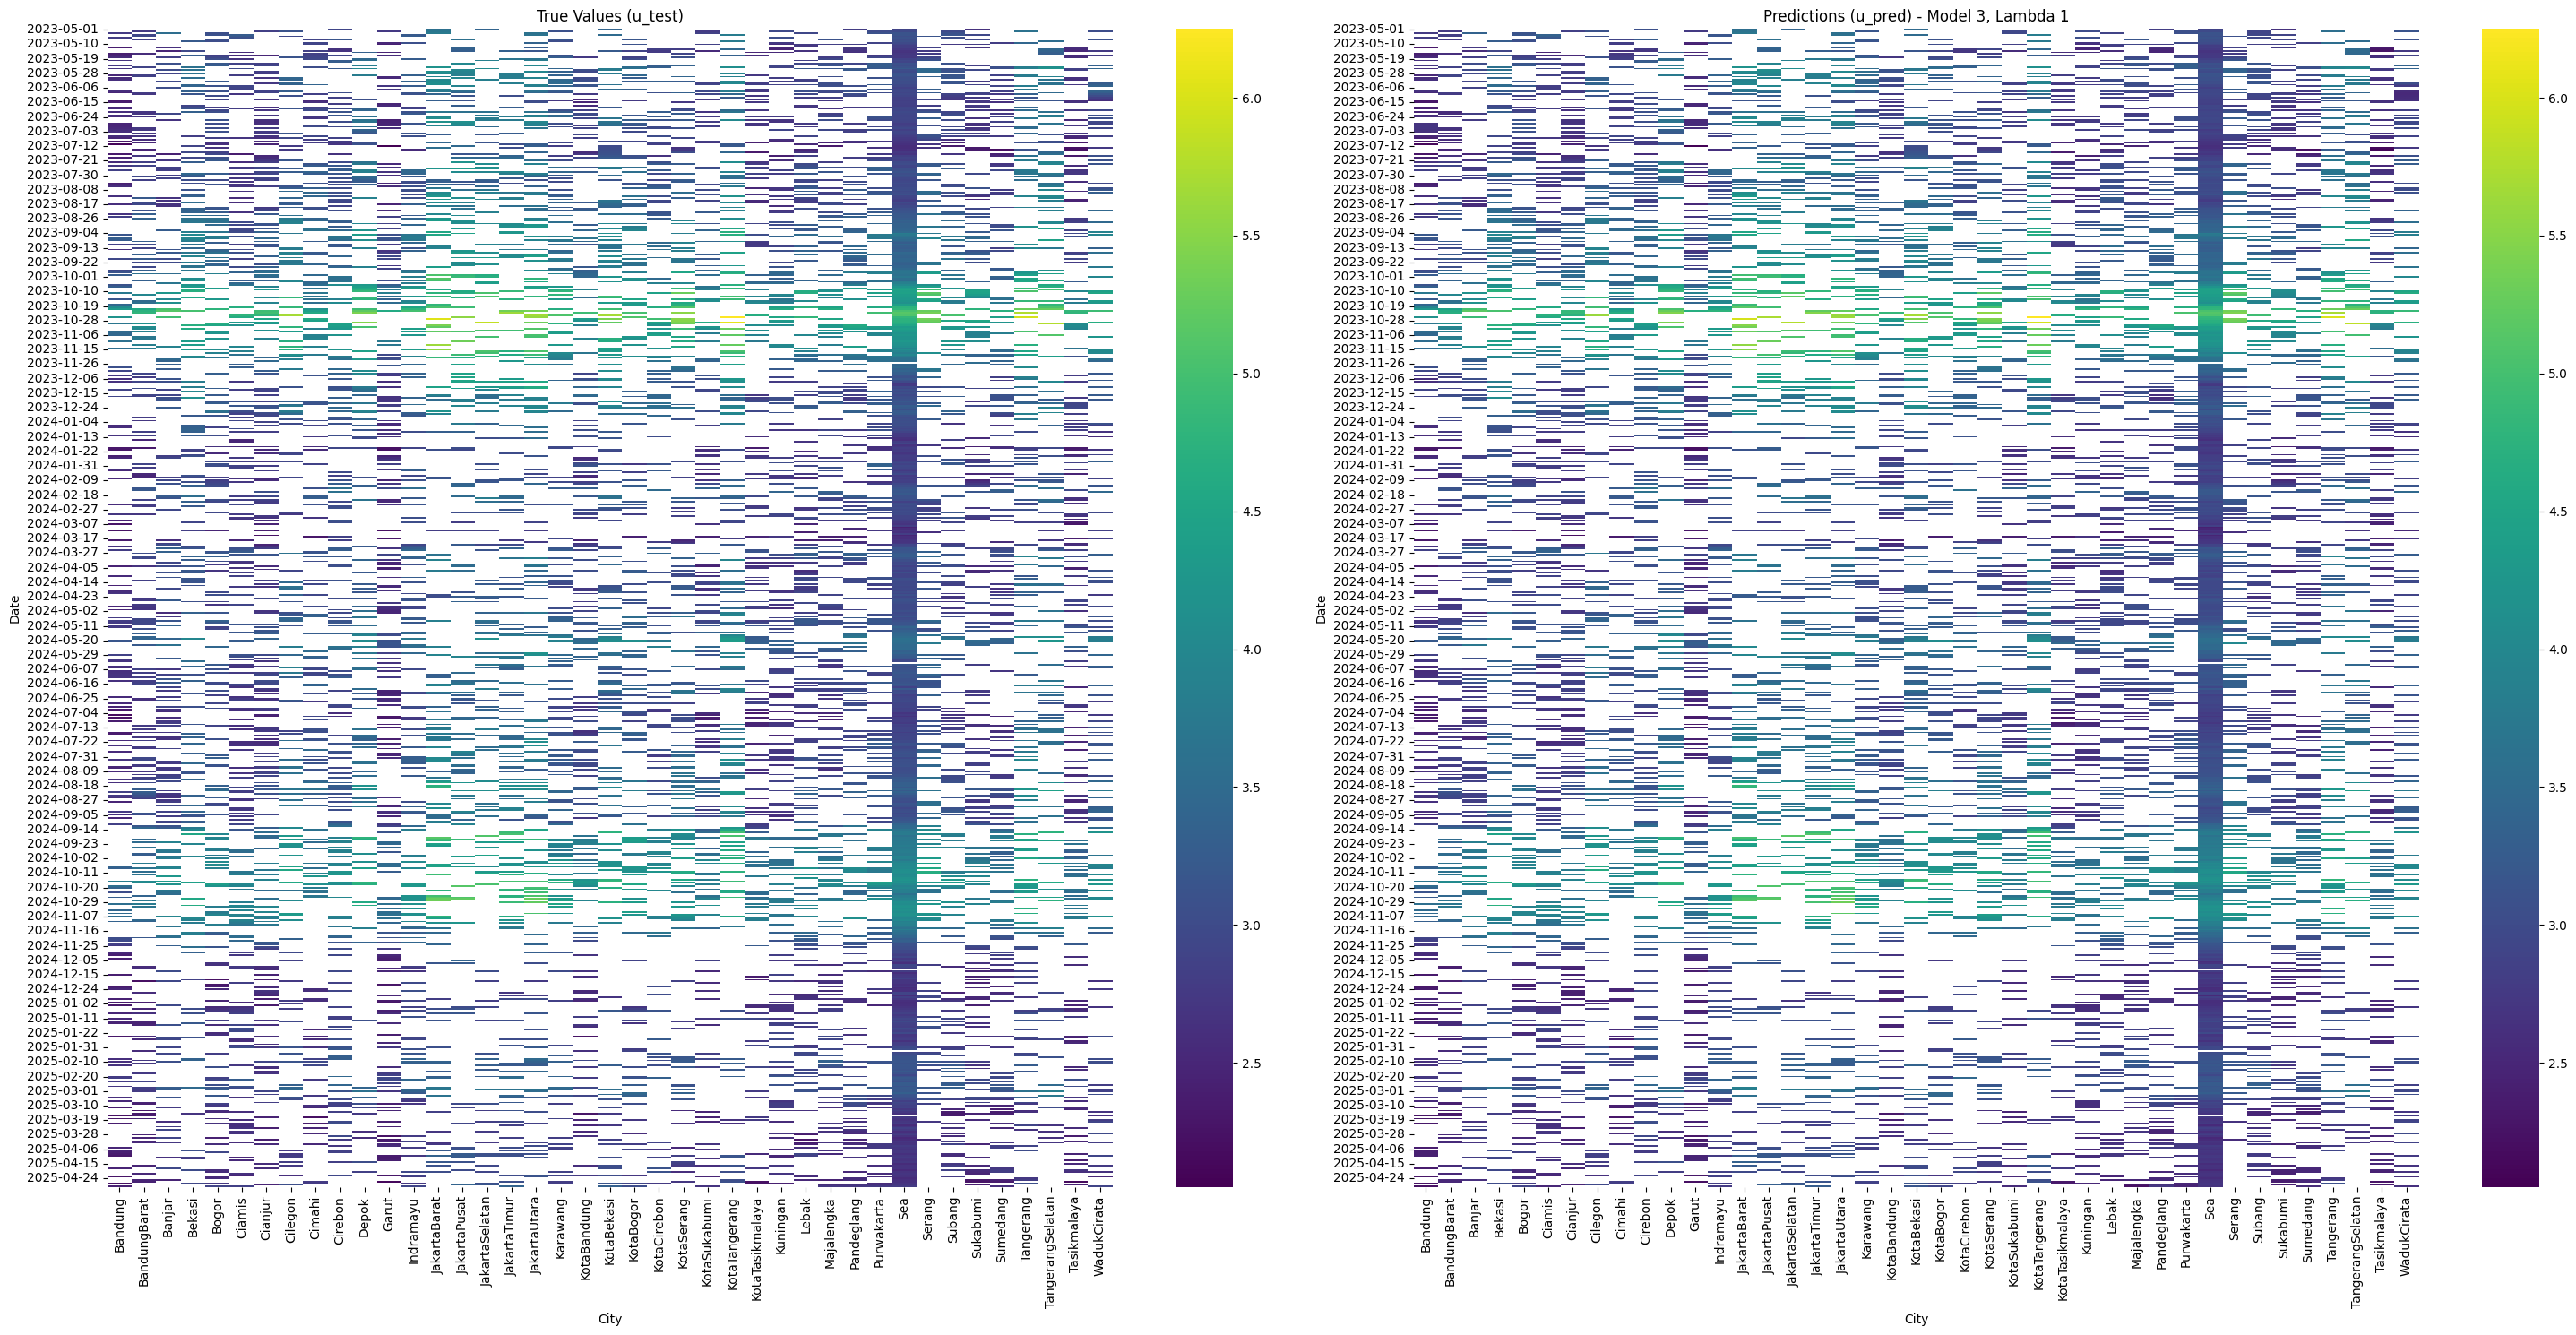

Loaded prediction data from: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_4_lambda_1.csv


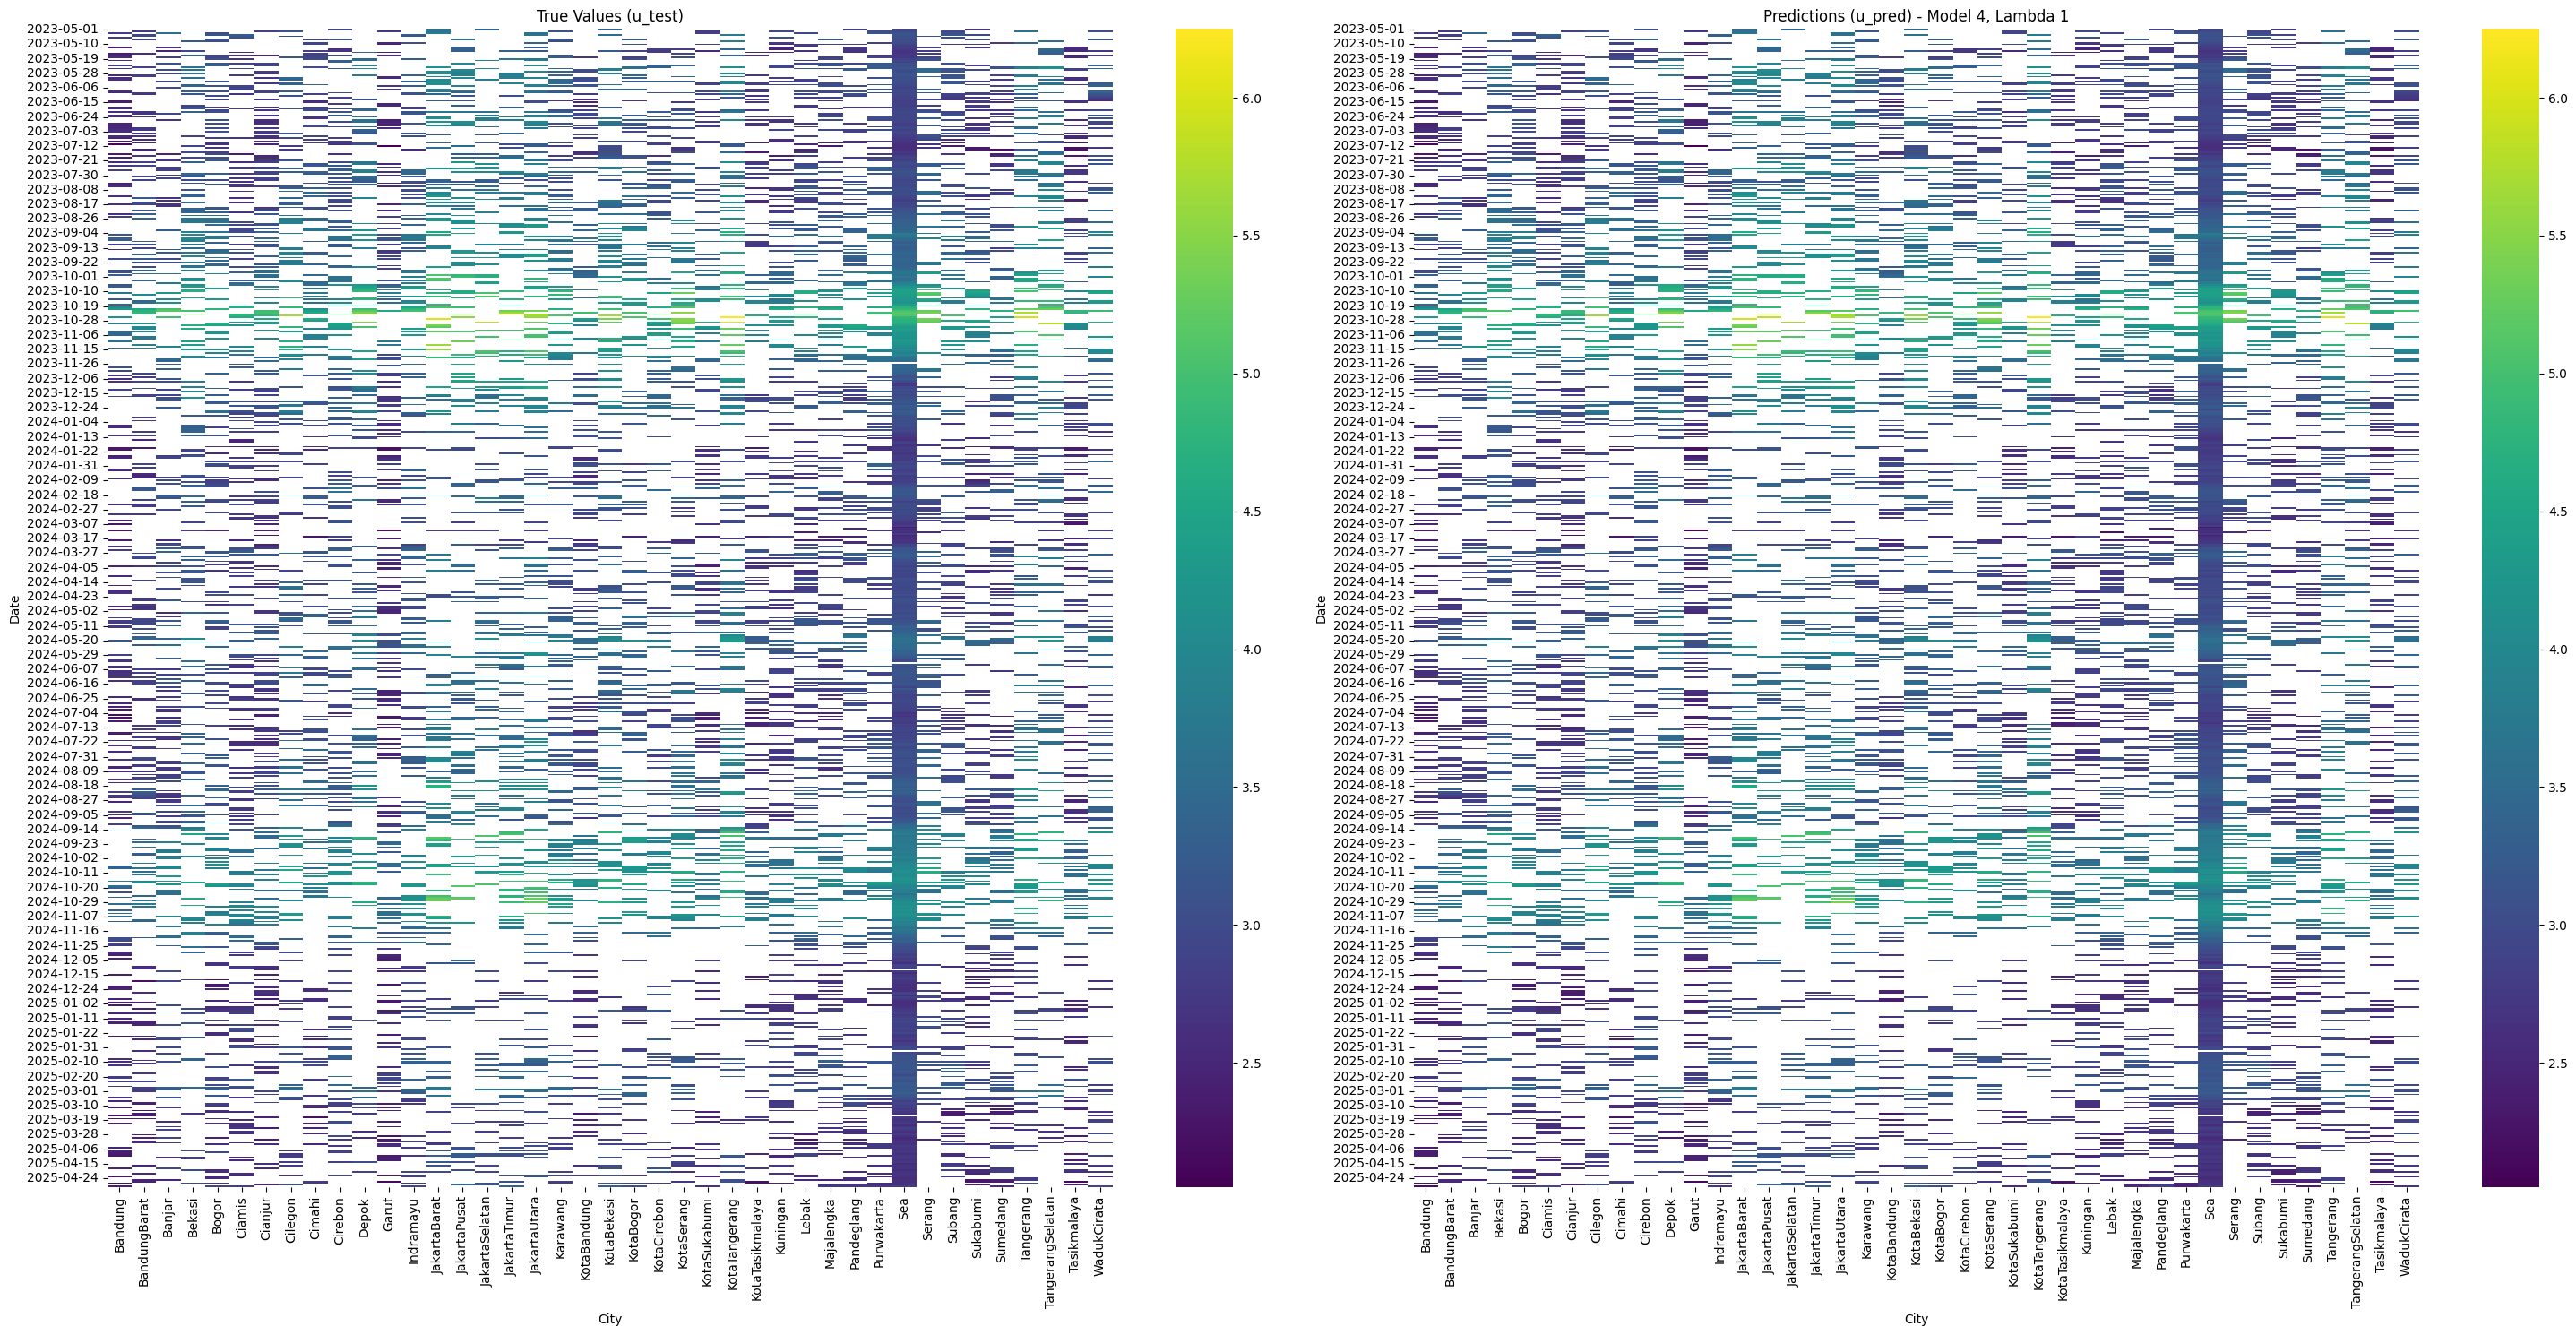

Loaded prediction data from: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish2/prediction_model_5_lambda_1.csv


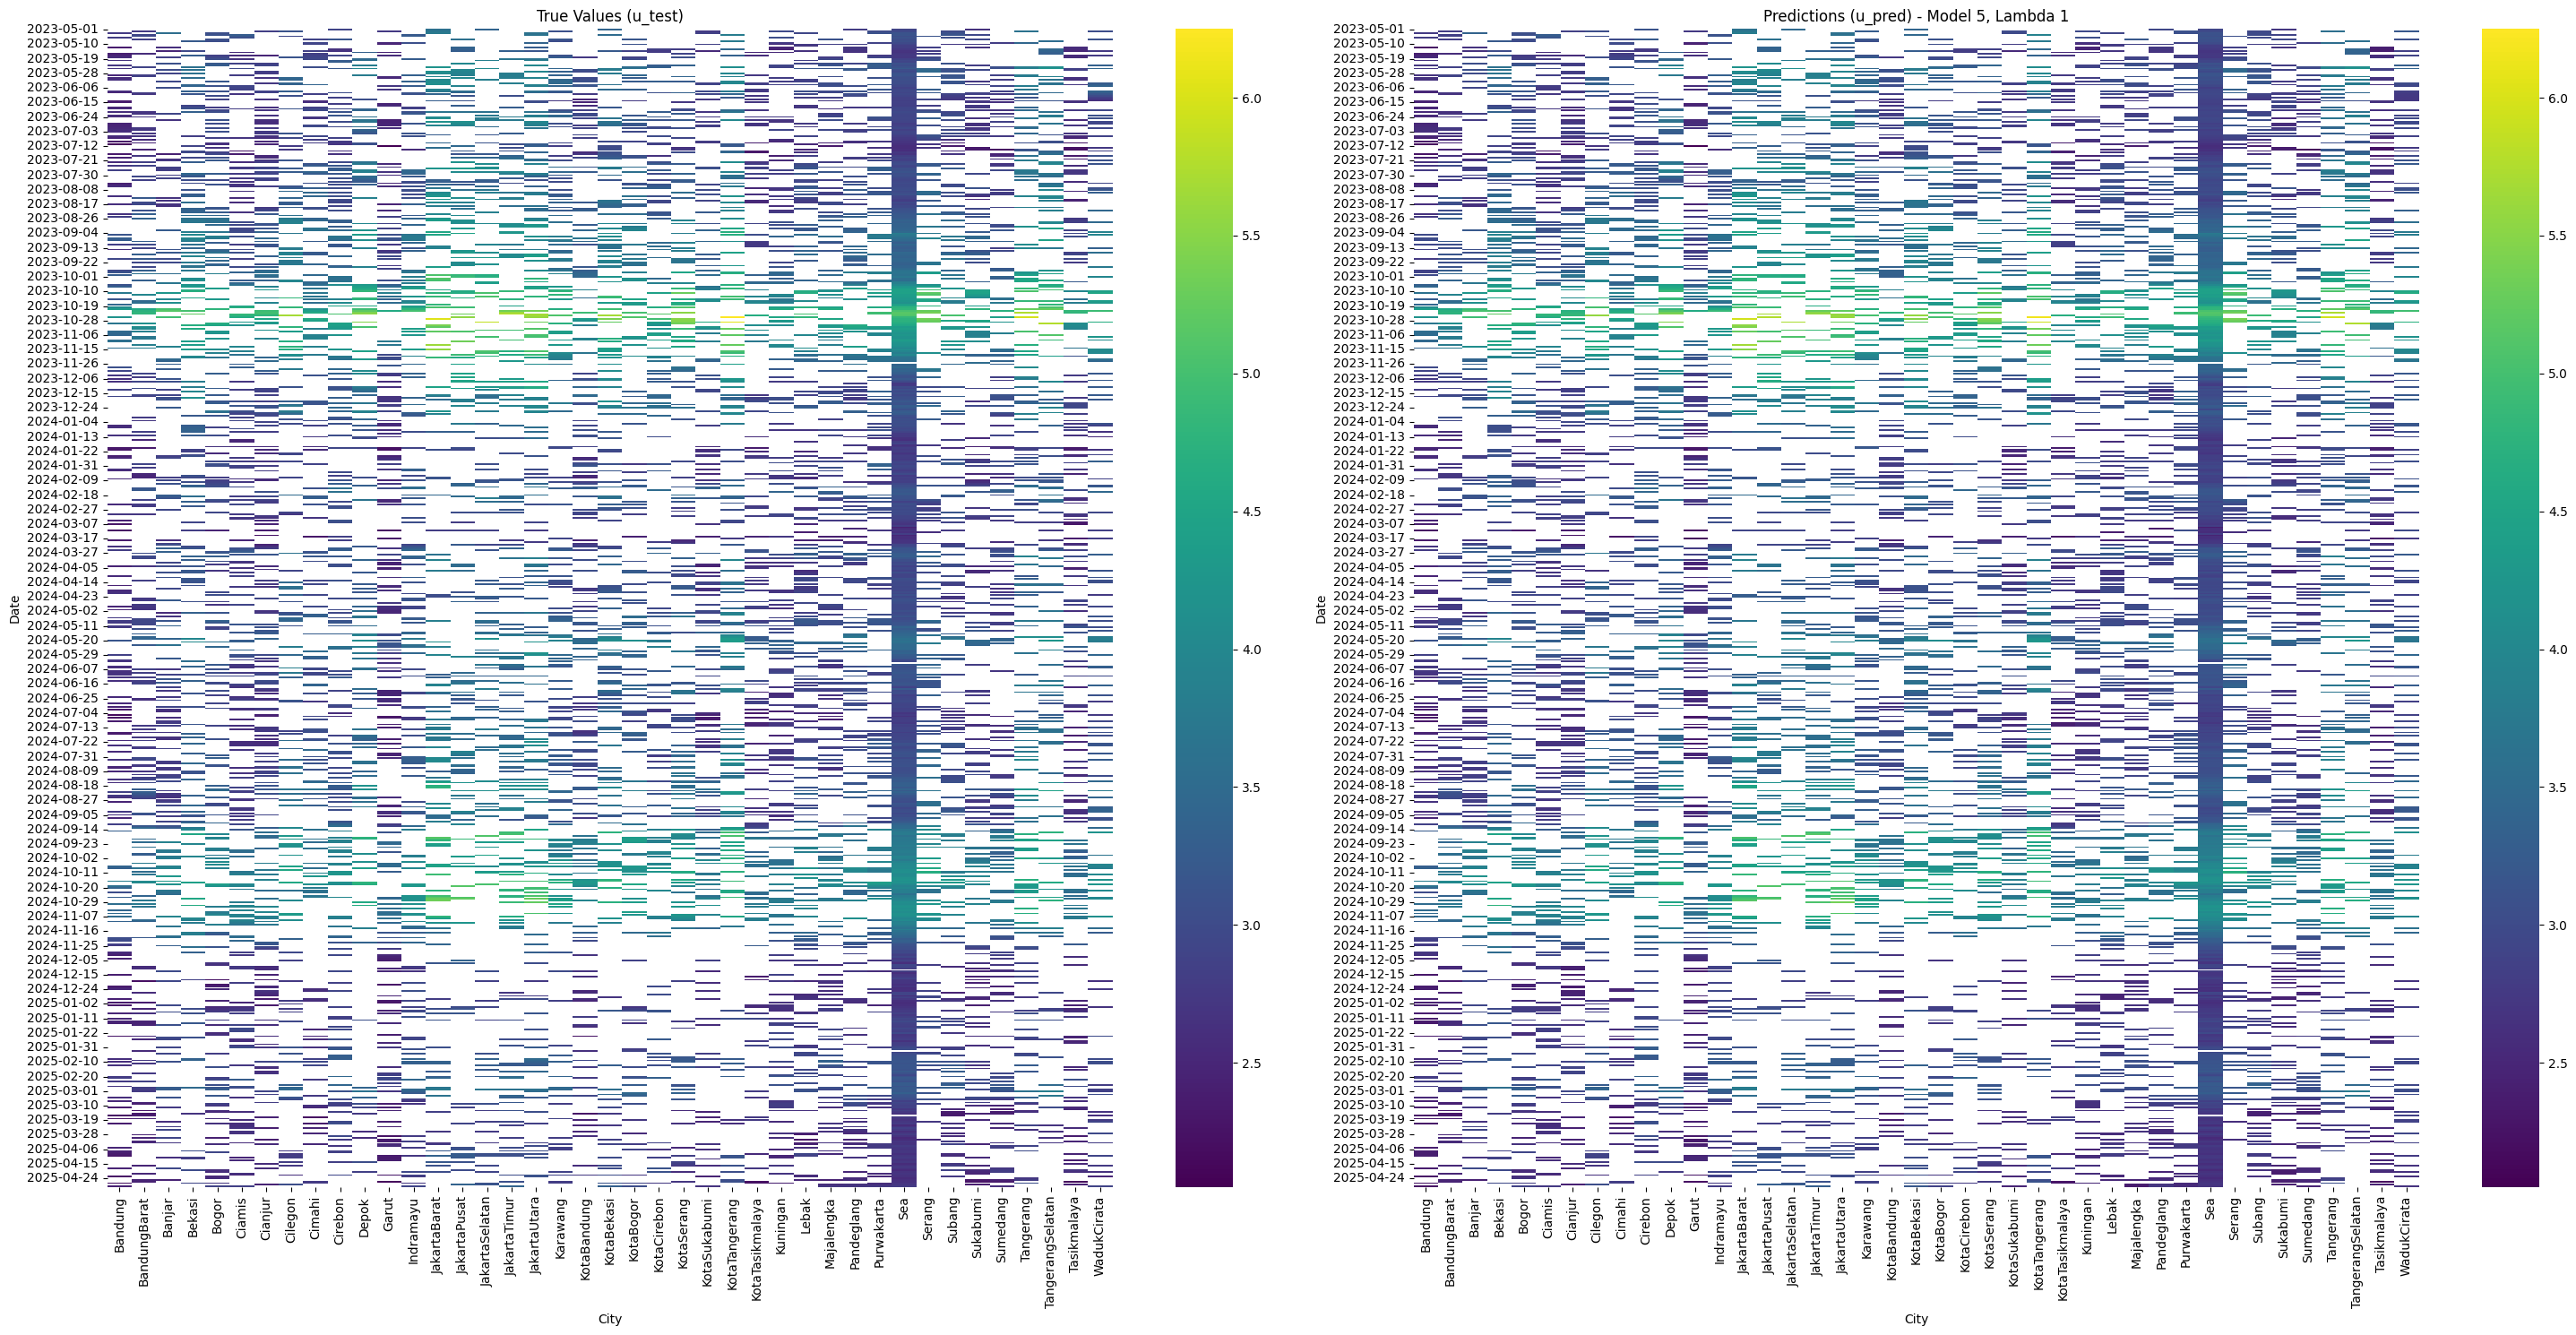

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np # Make sure numpy is imported for np.round
import datetime as dt
output_dir = dir + "COModel/Fourier/predictions/swish2/"

# Assuming X_test, u_test, and test_df are already loaded
# Convert X_test and u_test to numpy arrays for easier manipulation if they are not already
X_test_np = X_test.numpy() if isinstance(X_test, tf.Tensor) else X_test
u_test_np = u_test.numpy().flatten() if isinstance(u_test, tf.Tensor) else u_test.flatten()

# Ensure test_df is loaded and contains the 'city' column and 'date' column
# If not, load it or make sure it's available in your environment

# Extract city names and datetime objects from the original test_df
cities = test_df['city'].values
dates = test_df['date'].dt.date.values # Assuming 'date' column is already datetime


# n_models = 5
len_pred_lambda = 1 # Assuming the number of initial lambdas is 3

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_CO_mean'].values
        })

        # Pivot to get heatmap data using 'date' and 'city'
        heatmap_data_test = df.pivot_table(
            index='date',
            columns='city',
            values='u_test',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        heatmap_data_pred = df.pivot_table(
            index='date',
            columns='city',
            values='u_pred',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        # Determine shared color scale limits from the true data
        vmin = np.min(heatmap_data_test.min().min()) if not heatmap_data_test.empty else None
        vmax = np.max(heatmap_data_test.max().max()) if not heatmap_data_test.empty else None

        # Create the heatmap plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))

        # Plot true values with shared color scale
        if not heatmap_data_test.empty:
            sns.heatmap(heatmap_data_test, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax1)
        ax1.set_title('True Values (u_test)')
        ax1.set_xlabel('City')
        ax1.set_ylabel('Date')

        # Plot predictions with shared color scale
        if not heatmap_data_pred.empty:
             sns.heatmap(heatmap_data_pred, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax2)
        ax2.set_title(f'Predictions (u_pred) - Model {i+1}, Lambda {j+1}') # Dynamic title
        ax2.set_xlabel('City')
        ax2.set_ylabel('Date')

        plt.tight_layout()
        plt.show()

In [ ]:

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len(pred_lambda)):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df_recap = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_CO_mean'].values
        })
        nrows = 10
        ncols= 5
        unique_cities = df_recap['city'].unique()
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = axes.flatten() # Flatten the axes array for easy indexing

        # Iterate through unique cities and plot on their respective subplots
        for city_idx, city in enumerate(unique_cities):
            city_df = df_recap[df_recap['city'] == city].copy()

            sns.lineplot(data=city_df, x='date', y='u_test', label='True', ax=axes[city_idx])
            sns.lineplot(data=city_df, x='date', y='u_pred', label='Predicted', ax=axes[city_idx])

            axes[city_idx].set_title(f'{city}')
            axes[city_idx].set_xlabel('Date')
            axes[city_idx].set_ylabel('CO Mean')
            axes[city_idx].tick_params(axis='x', rotation=45)
            axes[city_idx].grid(True)
            axes[city_idx].legend()

        # Hide any unused subplots if the number of cities is not a multiple of ncols
        for k in range(41, nrows * ncols):
            fig.delaxes(axes[k])

        fig.suptitle(f'CO Mean Over Time (Model-{i+1}, Lambda-{j+1})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
weights = models_Adam_comb[0][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 6.19311810e-01 -1.36746216e+00  7.80801356e-01  1.72457492e+00
   8.58613253e-01  9.29100573e-01  3.06223094e-01  1.19047785e+00
   1.39141154e+00 -5.98115325e-01  1.24672778e-01  1.18766677e+00
  -1.16969585e+00 -1.90048015e+00 -2.04552078e+00 -1.72814596e+00
   1.18607426e+00  1.23642993e+00  2.83967614e-01  8.21256757e-01
   5.60189903e-01 -1.75322974e+00  2.90016551e-02  1.19146383e+00
  -7.04030752e-01  3.49801004e-01 -1.75579929e+00 -2.31576368e-01
   1.61081052e+00  5.43432236e-01  1.67782378e+00 -2.97964573e-01
   7.04850495e-01  8.50567341e-01 -6.17350936e-01  1.90043688e+00
  -6.32288039e-01 -1.38247800e+00  1.36700392e+00  1.97794580e+00
  -2.20175132e-01  1.48884904e+00  1.47610724e-01  9.52352062e-02
   1.70733258e-01 -7.68616080e-01 -8.72055233e-01 -5.44064164e-01
  -7.10943162e-01 -1.44480669e+00 -1.12108326e+00  5.54245293e-01
  -4.32998270e-01 -1.57124448e+00  9.99054790e-01 -1.37403774e+00
   1.89223206e+00  4.98547330e-02  5.68904877e-01 

In [ ]:
# import numpy as np
# import pandas as pd
# import math
# import os
# from google.colab import files

# # --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# # Misal Anda sudah memiliki filtered_df
# # Jika belum, upload:
# # uploaded = files.upload()
# # filtered_df = pd.read_csv("filtered_df.csv")

# step = 1e-2  # Resolusi

# t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
# x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
# y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

# t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
# x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
# y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# target_indices = [(1, 0), (3, 1), (0, 2)]
# models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
# model_labels   = [f"m{i}_{j}" for i, j in target_indices]
# file_paths     = [f"/content/prediction_Fourier2_swish_{label}.csv" for label in model_labels]

# # --- 3. Generator grid untuk batch prediksi ---

# def gen_batches(t_vec, x_vec, y_vec, batch_size=250_000):
#     for t in t_vec:
#         xy_pairs = np.stack(np.meshgrid(x_vec, y_vec, indexing="ij"), -1).reshape(-1, 2)
#         t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
#         tx_y = np.hstack([t_col, xy_pairs])
#         n_rows = tx_y.shape[0]
#         n_batch = math.ceil(n_rows / batch_size)
#         for k in range(n_batch):
#             yield tx_y[k * batch_size : (k + 1) * batch_size]

# # --- 4. Buat 3 file kosong dengan header masing-masing ---

# for path in file_paths:
#     if os.path.exists(path):
#         os.remove(path)
#     with open(path, "w") as f:
#         f.write("t,x,y,prediction\n")  # header standar

# # --- 5. Proses batch demi batch dan tulis per model ke file masing-masing ---

# for batch in gen_batches(t_points, x_points, y_points):
#     for model, path in zip(models_to_use, file_paths):
#         pred = model.predict(batch, verbose=0).reshape(-1, 1)  # asumsi 1 kolom
#         output = np.hstack([batch, pred])
#         pd.DataFrame(output, columns=["t", "x", "y", "prediction"])\
#           .to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

